# Génération des Statistiques du Rapport
Ce notebook permet d'analyser les métriques et statistiques d'annotation et de correction pour les shards Gold et Silver.

In [13]:
import pandas as pd
import os
import matplotlib.pyplot as plt

## Analyse du Gold Shard
Comparaison entre le fichier brut et la version validée manuellement.

--- ANALYSE DU GOLD SHARD (VALIDATION MANUELLE) ---
Total des lignes Gold : 1000
Nombre de lignes corrigées manuellement : 282
Taux de correction manuelle : 28.20%


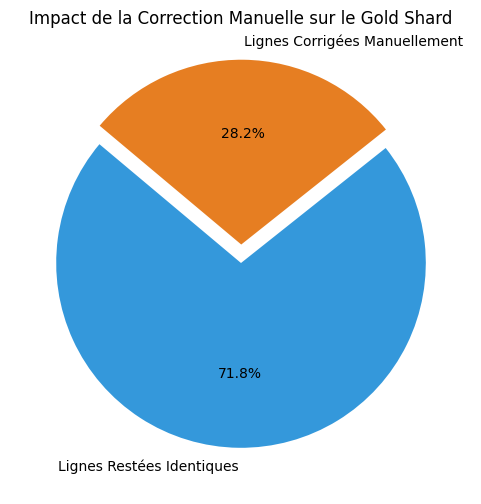

In [14]:
# Ajout des chemins nécessaires pour le Gold shard
gold_initial_path = '../../shards/gold/gold_shard_1.csv'
gold_final_path = '../deliverables/gold_shard_1_final.csv'

df_gold_init = pd.read_csv(gold_initial_path)
df_gold_final = pd.read_csv(gold_final_path)

# On merge sur data_id
df_gold_comp = pd.merge(df_gold_init, df_gold_final, on='data_id', suffixes=('_init', '_final'))

# Calcul des erreurs/changements
# On compare le Darija Arabic pour voir les corrections de fond
gold_diffs = (df_gold_comp['darija_arabic_init'] != df_gold_comp['darija_arabic_final']).sum()

print("--- ANALYSE DU GOLD SHARD (VALIDATION MANUELLE) ---")
print(f"Total des lignes Gold : {len(df_gold_init)}")
print(f"Nombre de lignes corrigées manuellement : {gold_diffs}")
print(f"Taux de correction manuelle : {(gold_diffs / len(df_gold_init)) * 100:.2f}%")

# Visualisation
plt.figure(figsize=(6, 6))
labels_gold = ['Lignes Restées Identiques', 'Lignes Corrigées Manuellement']
sizes_gold = [len(df_gold_init) - gold_diffs, gold_diffs]
colors_gold = ['#3498db', '#e67e22']

plt.pie(sizes_gold, labels=labels_gold, autopct='%1.1f%%', startangle=140, colors=colors_gold, explode=(0, 0.1))
plt.title('Impact de la Correction Manuelle sur le Gold Shard')
plt.show()

## Analyse du Silver Shard
Comparaison entre le fichier brut et la version corrigée.

Lignes Initiales : 9005
Lignes Clean/Corrected (AI) : 9005
Lignes Finales (Manual) : 9005

--- ANALYSE DE L'ÉVOLUTION DU NETTOYAGE ---
1. Changements effectues par l'Auto-Correction (IA) : 8652 lignes modifiées
2. Changements effectues par la Correction Manuelle finale : 1 lignes modifiées


C:\Users\X1\AppData\Local\Temp\ipykernel_23012\612392111.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=evol_data.index, y=evol_data.values, palette='coolwarm')


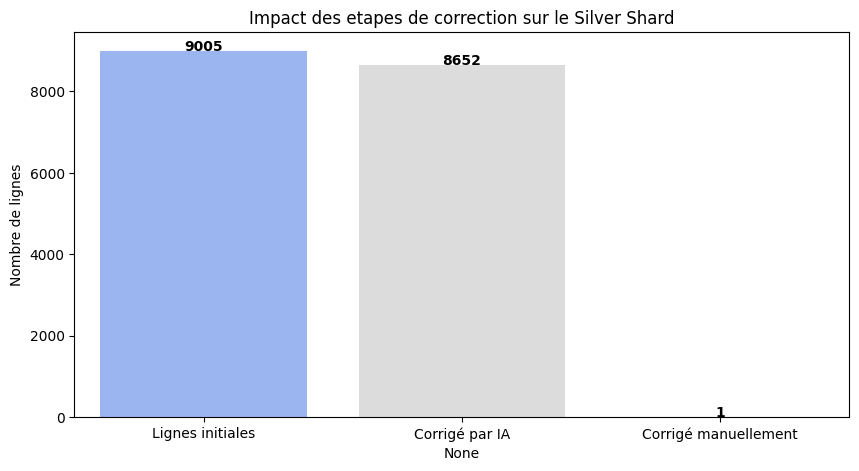


Exemple d'une ligne corrigée par l'IA PUIS manuellement (1 cas) :


,data_id,darija_arabic_init,darija_arabic_aiclean,darija_arabic
2795,data57829,ب تعديل قوانين أخرى، عاون باش يمنع تمويل ديال ...,ب تعديل قوانين أخرى، عاون باش يمنع تمويل ديال ...,بتعديل قوانين أخرى، عاون باش يمنع تمويل ديال ا...


In [15]:
import seaborn as sns

# Ajout des chemins nécessaires d'après le contexte
silver_ia_initial = '../../shards/silver/silver_shard_1.csv'
silver_ia_clean_cor = 'silver_shard_1_clean_corrected.csv'
silver_final = '../deliverables/silver_shard_1_final.csv'

df_ia_init = pd.read_csv(silver_ia_initial)
df_ia_clean = pd.read_csv(silver_ia_clean_cor)
df_final_man = pd.read_csv(silver_final)

# On aligne sur data_id
print(f"Lignes Initiales : {len(df_ia_init)}")
print(f"Lignes Clean/Corrected (AI) : {len(df_ia_clean)}")
print(f"Lignes Finales (Manual) : {len(df_final_man)}")

# On merge les 3 versions sur 'data_id' pour voir les évolutions
df_evolution = pd.merge(df_ia_init, df_ia_clean, on='data_id', suffixes=('_init', '_aiclean'))
df_evolution = pd.merge(df_evolution, df_final_man, on='data_id')

# Comparaison des changements
# Etape 1: Changements apportés par l'auto-nettoyage IA
diff_auto = (df_evolution['darija_arabic_init'] != df_evolution['darija_arabic_aiclean']).sum()
# Etape 2: Changements apportés par la correction manuelle finale
diff_manual = (df_evolution['darija_arabic_aiclean'] != df_evolution['darija_arabic']).sum()

print("\n--- ANALYSE DE L'ÉVOLUTION DU NETTOYAGE ---")
print(f"1. Changements effectues par l'Auto-Correction (IA) : {diff_auto} lignes modifiées")
print(f"2. Changements effectues par la Correction Manuelle finale : {diff_manual} lignes modifiées")

# Visualisation de l'apport
plt.figure(figsize=(10, 5))
evol_data = pd.Series({
    'Lignes initiales': len(df_ia_init),
    'Corrigé par IA': diff_auto,
    'Corrigé manuellement': diff_manual
})

sns.barplot(x=evol_data.index, y=evol_data.values, palette='coolwarm')
plt.title('Impact des etapes de correction sur le Silver Shard')
plt.ylabel('Nombre de lignes')
for i, v in enumerate(evol_data.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()

# Exemple d'une ligne ayant subi les deux corrections (si elle existe)
both_fixed = df_evolution[(df_evolution['darija_arabic_init'] != df_evolution['darija_arabic_aiclean']) & 
                          (df_evolution['darija_arabic_aiclean'] != df_evolution['darija_arabic'])]

if not both_fixed.empty:
    print(f"\nExemple d'une ligne corrigée par l'IA PUIS manuellement ({len(both_fixed)} cas) :")
    display(both_fixed[['data_id', 'darija_arabic_init', 'darija_arabic_aiclean', 'darija_arabic']].head(1))
else:
    print("\nAucun exemple de ligne corrigée successivement par l'IA et manuellement.")